
Plotting top 15 Commentaire clusters (each with top 10 Description correlations)...


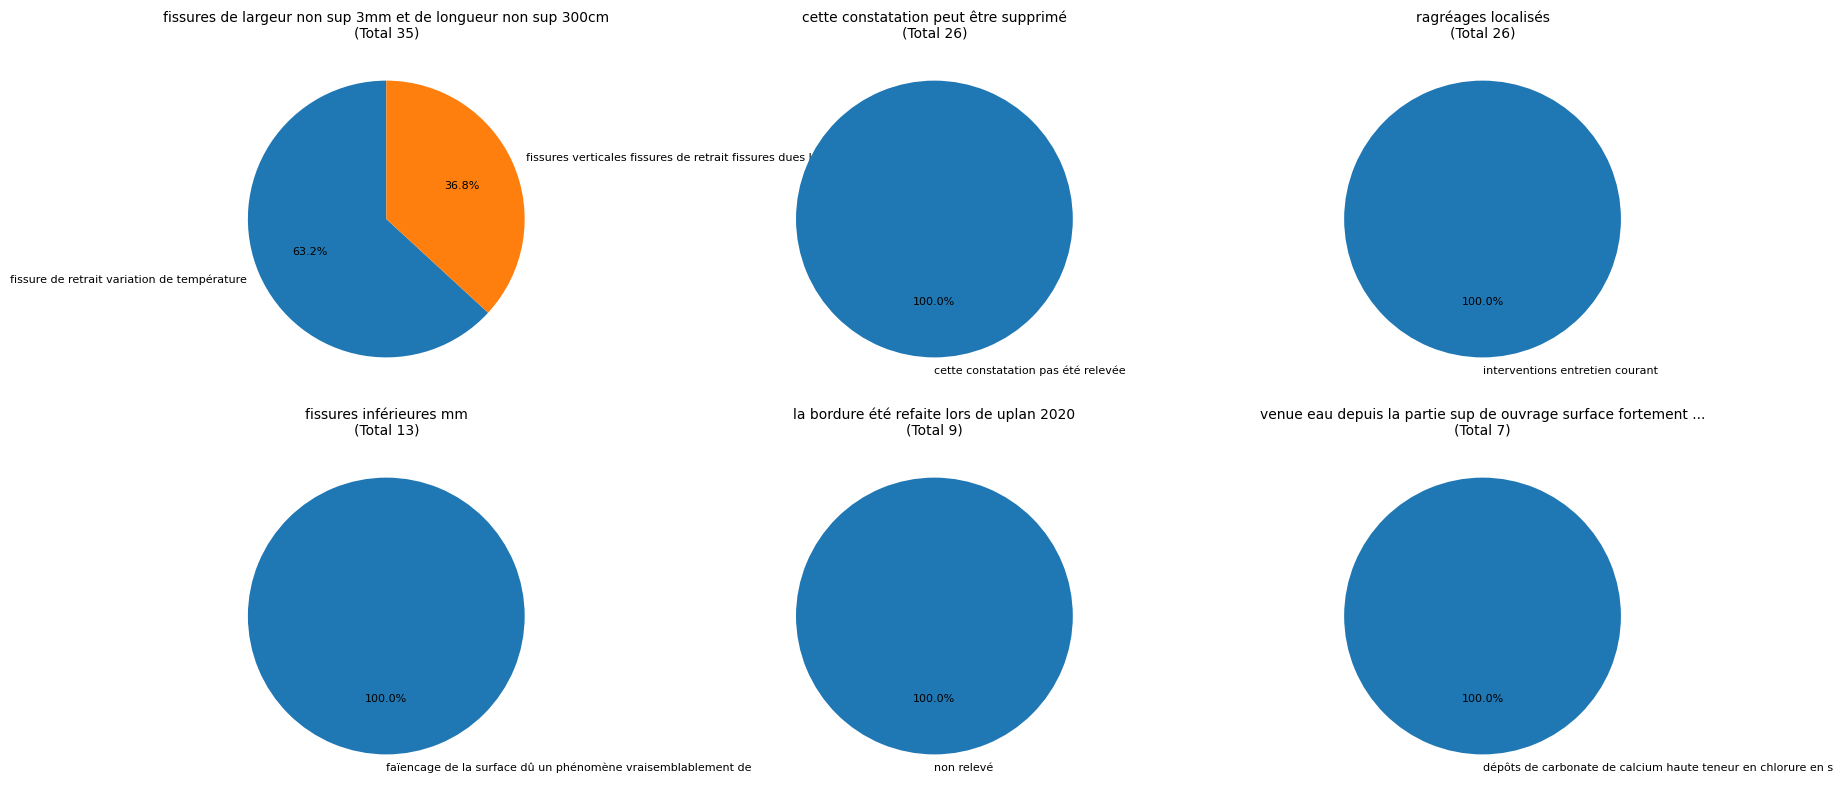

✅ Saved 'top15_commentaire_description_pies.png'.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

corr_file = "commentaire_description_correlations_fulltext.csv"
max_desc_per_pie = 10

corr_df = pd.read_csv(corr_file, sep=";")
if corr_df.empty:
    raise ValueError("No correlation data found. Run Part 1 first.")

corr_df = corr_df.dropna(subset=["Commentaire_Cluster", "Description_Cluster"])
corr_df = corr_df[
    (corr_df["Commentaire_Cluster"].astype(str).str.strip() != "") &
    (corr_df["Description_Cluster"].astype(str).str.strip() != "")
]

print("\nPlotting top 15 Commentaire clusters (each with top 10 Description correlations)...")

top_comm = (
    corr_df.groupby("Commentaire_Cluster")["Commentaire_Count"]
    .max()
    .sort_values(ascending=False)
    .head(15)
    .index
)

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, comm in enumerate(top_comm):
    ax = axes[i]
    subset = corr_df[corr_df["Commentaire_Cluster"] == comm]
    subset = subset.sort_values(by="Description_Count", ascending=False).head(max_desc_per_pie)
    sizes = subset["Description_Count"]
    labels = subset["Description_Cluster"].astype(str).str.slice(0, 60)
    ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 8})
    title = comm[:60] + ("..." if len(comm) > 60 else "")
    ax.set_title(f"{title}\n(Total {subset['Commentaire_Count'].iloc[0]})", fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("top15_commentaire_description_pies.png", dpi=300)
plt.show()
print("✅ Saved 'top15_commentaire_description_pies.png'.")
